In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the IoT sensor dataset
df = pd.read_csv("/content/Dataset.csv")

print("Dataset shape:", df.shape)

print("\nFirst 5 rows:")
display(df.head())

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

Dataset shape: (4000, 14)

First 5 rows:


,t_ms,gas_raw,temp_c,flame,gas_avg,temp_avg,dGas,dTemp,ml_state,final_state,alarm,suppression,label,label_name
0,1000,123,38.0,0,123.0,38.0,0.0,0.00,0,0,0,0,0,NORMAL
1,2000,309,32.6,0,216.0,35.3,93.0,-2.70,0,0,0,0,0,NORMAL
2,3000,276,34.7,0,236.0,35.1,20.0,-0.20,0,0,0,0,0,NORMAL
3,4000,222,32.5,0,232.5,34.5,-3.5,-0.65,0,0,0,0,0,NORMAL
4,5000,220,31.7,0,230.0,33.9,-2.5,-0.55,0,0,0,0,0,NORMAL



Column names:
['t_ms', 'gas_raw', 'temp_c', 'flame', 'gas_avg', 'temp_avg', 'dGas', 'dTemp', 'ml_state', 'final_state', 'alarm', 'suppression', 'label', 'label_name']

Data types:
t_ms             int64
gas_raw          int64
temp_c         float64
flame            int64
gas_avg        float64
temp_avg       float64
dGas           float64
dTemp          float64
ml_state         int64
final_state      int64
alarm            int64
suppression      int64
label            int64
label_name      object
dtype: object

Missing values:
t_ms           0
gas_raw        0
temp_c         0
flame          0
gas_avg        0
temp_avg       0
dGas           0
dTemp          0
ml_state       0
final_state    0
alarm          0
suppression    0
label          0
label_name     0
dtype: int64


In [2]:
# Check dataset quality and target distribution

print("Missing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nUnique values in each column:")
print(df.nunique())

print("\nFinal state distribution:")
print(df["final_state"].value_counts())

print("\nPercentage distribution:")
print(df["final_state"].value_counts(normalize=True) * 100)

Missing values:
t_ms           0
gas_raw        0
temp_c         0
flame          0
gas_avg        0
temp_avg       0
dGas           0
dTemp          0
ml_state       0
final_state    0
alarm          0
suppression    0
label          0
label_name     0
dtype: int64

Duplicate rows:
0

Unique values in each column:
t_ms           4000
gas_raw         805
temp_c          742
flame             2
gas_avg        1753
temp_avg        633
dGas            655
dTemp           452
ml_state          4
final_state       4
alarm             2
suppression       2
label             4
label_name        4
dtype: int64

Final state distribution:
final_state
3    1638
0    1007
1     998
2     357
Name: count, dtype: int64

Percentage distribution:
final_state
3    40.950
0    25.175
1    24.950
2     8.925
Name: proportion, dtype: float64


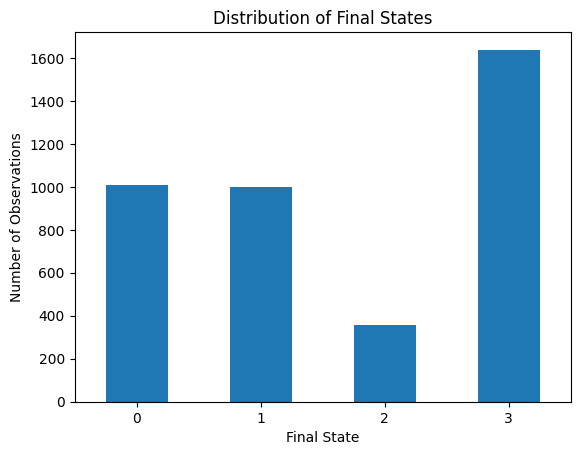

In [3]:
import matplotlib.pyplot as plt

# Plot distribution of the target classes
df["final_state"].value_counts().sort_index().plot(kind="bar")

plt.title("Distribution of Final States")
plt.xlabel("Final State")
plt.ylabel("Number of Observations")
plt.xticks(rotation=0)
plt.show()

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# Features we will use to predict the final state
features = [
    "gas_raw",
    "temp_c",
    "flame",
    "gas_avg",
    "temp_avg",
    "dGas",
    "dTemp"
]

X = df[features]
y = df["final_state"]

# Split: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 3200
Testing samples: 800


In [5]:
# Create the Random Forest model
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

# Train the model
model.fit(X_train, y_train)

# Make predictions on unseen test data
y_pred = model.predict(X_test)

print("Model training complete!")
print("Accuracy:", accuracy_score(y_test, y_pred))

Model training complete!
Accuracy: 0.98375


Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       201
           1       1.00      1.00      1.00       200
           2       0.90      0.93      0.92        71
           3       0.98      0.98      0.98       328

    accuracy                           0.98       800
   macro avg       0.97      0.98      0.97       800
weighted avg       0.98      0.98      0.98       800


Confusion Matrix:
[[200   1   0   0]
 [  0 200   0   0]
 [  0   0  66   5]
 [  0   0   7 321]]


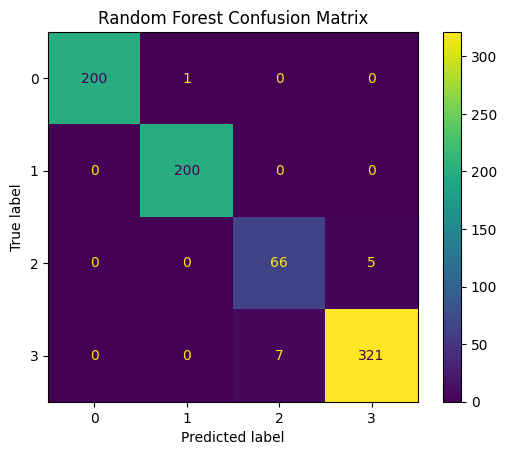

In [6]:
# Detailed model evaluation
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

# Visualise confusion matrix
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=model.classes_
)

disp.plot()
plt.title("Random Forest Confusion Matrix")
plt.show()

    Feature  Importance
4  temp_avg    0.380216
1    temp_c    0.239023
3   gas_avg    0.157987
0   gas_raw    0.133038
2     flame    0.053601
6     dTemp    0.027465
5      dGas    0.008670


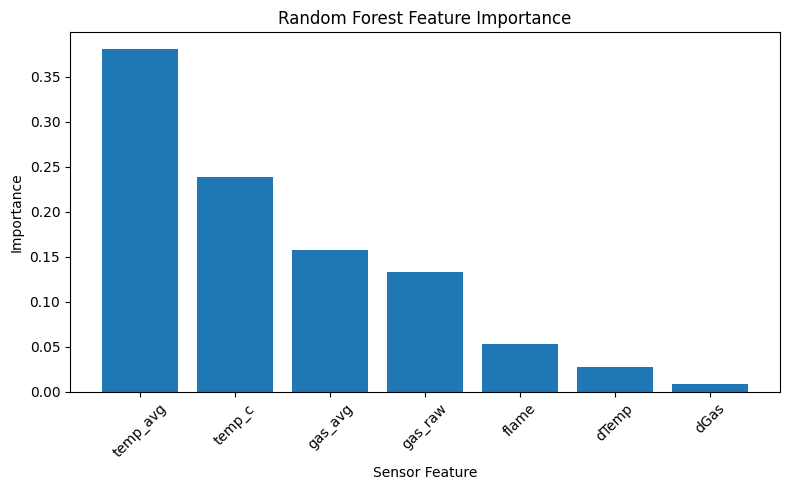

In [7]:
# Feature importance
importances = model.feature_importances_

importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print(importance_df)

plt.figure(figsize=(8, 5))
plt.bar(importance_df["Feature"], importance_df["Importance"])
plt.title("Random Forest Feature Importance")
plt.xlabel("Sensor Feature")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [8]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Create baseline Logistic Regression model
lr_model = make_pipeline(
    StandardScaler(),
    LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    )
)

# Train
lr_model.fit(X_train, y_train)

# Predict
lr_pred = lr_model.predict(X_test)

# Evaluate
lr_accuracy = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy:", lr_accuracy)
print("\nClassification Report:")
print(classification_report(y_test, lr_pred))

Logistic Regression Accuracy: 0.95875

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       201
           1       1.00      1.00      1.00       200
           2       0.69      1.00      0.82        71
           3       1.00      0.90      0.95       328

    accuracy                           0.96       800
   macro avg       0.92      0.97      0.94       800
weighted avg       0.97      0.96      0.96       800



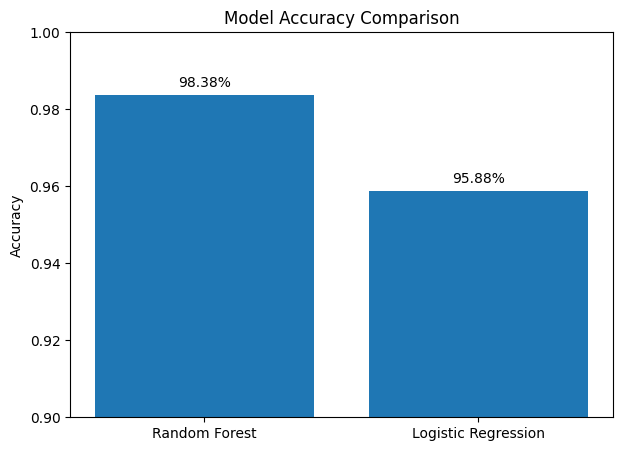

In [9]:
# Compare model performance
model_names = ["Random Forest", "Logistic Regression"]
accuracies = [accuracy_score(y_test, y_pred), lr_accuracy]

plt.figure(figsize=(7, 5))
plt.bar(model_names, accuracies)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0.90, 1.00)

for i, value in enumerate(accuracies):
    plt.text(i, value + 0.002, f"{value:.2%}", ha="center")

plt.show()

In [10]:
# Check which features were used to predict final_state
print("Target: final_state")
print("Features used:")
print(features)

print("\nCorrelations with final_state:")
check_cols = features + ["final_state"]
print(
    df[check_cols]
    .corr()["final_state"]
    .sort_values(ascending=False)
)

Target: final_state
Features used:
['gas_raw', 'temp_c', 'flame', 'gas_avg', 'temp_avg', 'dGas', 'dTemp']

Correlations with final_state:
final_state    1.000000
temp_avg       0.972764
temp_c         0.962760
flame          0.619278
gas_avg        0.325350
gas_raw        0.312913
dGas           0.004683
dTemp         -0.012152
Name: final_state, dtype: float64


In [11]:
# Final results summary

print("=" * 50)
print("IoT ANOMALY DETECTION - FINAL RESULTS")
print("=" * 50)

print(f"\nDataset observations: {len(df)}")
print(f"Number of input features: {len(features)}")
print(f"Training observations: {len(X_train)}")
print(f"Testing observations: {len(X_test)}")

print("\nMODEL PERFORMANCE")
print(f"Random Forest Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Logistic Regression Accuracy: {lr_accuracy:.4f}")

print("\nBest Random Forest features:")
print(importance_df.head(5).to_string(index=False))

print("\nRandom Forest Classification Report:")
print(classification_report(y_test, y_pred))

IoT ANOMALY DETECTION - FINAL RESULTS

Dataset observations: 4000
Number of input features: 7
Training observations: 3200
Testing observations: 800

MODEL PERFORMANCE
Random Forest Accuracy: 0.9838
Logistic Regression Accuracy: 0.9587

Best Random Forest features:
 Feature  Importance
temp_avg    0.380216
  temp_c    0.239023
 gas_avg    0.157987
 gas_raw    0.133038
   flame    0.053601

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       201
           1       1.00      1.00      1.00       200
           2       0.90      0.93      0.92        71
           3       0.98      0.98      0.98       328

    accuracy                           0.98       800
   macro avg       0.97      0.98      0.97       800
weighted avg       0.98      0.98      0.98       800

